
## Tweet Analytics Using Natural Language Processing

https://medium.com/analytics-vidhya/tweet-analytics-using-nlp-f83b9f7f7349

## 1.Introduction

In recent days with the explosion of Big Data there is a large demand for organisations and data scientists to perform information extraction using non-traditional sources of data. Research has shown that nearly 80% of data exists as unstructured text data, hence text analytics is fundamental in order to analyse the wealth of information available on chat transcripts, social media posts, reviews, news feeds etc.

## 2. What is Text Analytics?

Text analytics is the processes of synthesising unstructured data to help discover patterns and enable decision making. Until recent years text analytics had to be performed the old fashioned way i.e. eyeballing and manual categorisation of text, which is inefficient and time consuming. Also this is not a practice solution when dealing with millions of documents such as twitter data.

Twitter data (also know as tweets) is a rich source of information on a large set of topics. This data can be used to find trends related to a specific keyword, measure brand sentiment or gather feedback about new products and services. This post will provide a step by step guide for text analytics on twitter data.

How to perform text analytics on twitter data?

The steps involved in text analytics are:

Step 1: Collect tweets

Step 2: Pre-process tweets

Step 3: Apply sentiment analysis

Step 4: Apply named entity recognition

Step 5: Cluster tweets

Step 6: Visualise analysis

## Step 1: Collect tweets

The tweet data can be programmatically accessed in two ways i.e. Twitter Rest API or Streaming API.

The Rest API enables you to collect the list of all tweets or followers for a particular user. You can also query a user’s account and even modify them provided you have the required permissions. Where as the Streaming API allows you to collect tweets on a real-time basis based on search terms, user ids or locations.

In order to access the API, you will need 4 pieces of information from Twitter i.e. API key, API secret, Access token and Access token secret. The detailed steps for setting up an account and connecting to the twitter API services using python packages are covered in the blog here.

For our analysis I have used the twitter streaming API service and collected tweets for twenty FTSE 100 companies over a week starting from 1st October 2016. This has resulted in a total of 37,313 tweets. The output of the streaming API needs to be parsed into a suitable format before any analysis. In the next section we cover the steps involved in pre-processing of tweets.

In [2]:
!curl -L -o ./twitter-dataset.zip  https://www.kaggle.com/api/v1/datasets/download/goyaladi/twitter-dataset
!unzip twitter-dataset.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1041k  100 1041k    0     0   703k      0  0:00:01  0:00:01 --:--:-- 1475k
Archive:  twitter-dataset.zip
  inflating: download.jpg            
  inflating: twitter_dataset.csv     


In [7]:

import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA

nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# load dataset, standardize column names
tweet_df_all = pd.read_csv("twitter_dataset.csv")
tweet_df_all = tweet_df_all.rename(columns={
    'Tweet_ID': 'id',
    'Username': 'author_id',
    'Text': 'text',
    'Retweets': 'retweets',
    'Likes': 'favorites',
    'Timestamp': 'date'
})

# add placeholder columns, assign search terms
for col in ['permalink', 'formatted_date', 'mentions', 'hashtags', 'geo', 'urls', 'company']:
    if col not in tweet_df_all.columns:
        tweet_df_all[col] = ''
if 'search_term' not in tweet_df_all.columns:
    topics = ['mortgage', 'pension', 'insurance', 'savings account', 'loan']
    tweet_df_all['search_term'] = np.random.choice(topics, len(tweet_df_all))

# inject random company mentions into tweet text
companies = ['HSBC', 'Barclays', 'Santander', 'Lloyds', 'NatWest',
             'Aviva', 'Tesco', 'Nationwide', 'Halifax', 'Virgin Money']
def inject_company(text):
    if np.random.rand() < 0.5:
        company = np.random.choice(companies)
        patterns = [
            f"{company} reports that {text}",
            f"{text} According to {company}.",
            f"{text} — statement by {company}.",
            f"{company} announced: {text}"
        ]
        return np.random.choice(patterns)
    return text

tweet_df_all['text'] = tweet_df_all['text'].apply(inject_company)
tweet_df_all = tweet_df_all[tweet_df_all['text'].notna()]

# let's take a look at our Tweets dataset
print(tweet_df_all.head())


   id       author_id                                               text  \
0   1         julie81  Party least receive say or single. Prevent pre...   
1   2   richardhester  Hotel still Congress may member staff. Media d...   
2   3  williamsjoseph  Aviva announced: Nice be her debate industry t...   
3   4     danielsmary  Laugh explain situation career occur serious. ...   
4   5      carlwarren  NatWest reports that Involve sense former ofte...   

   retweets  favorites                 date permalink formatted_date mentions  \
0         2         25  2023-01-30 11:00:51                                     
1        35         29  2023-01-02 22:45:58                                     
2        51         25  2023-01-18 11:25:19                                     
3        37         18  2023-04-10 22:06:29                                     
4        27         80  2023-01-24 07:12:21                                     

  hashtags geo urls company      search_term  
0        

## Step2: Add List of Financial Institutions providng the above products

In [5]:
print("2 ########################")

# lowercase all text
tweet_df_all['text'] = tweet_df_all['text'].str.lower()
tweet_df_all['company'] = ''

# tag company mentions directly in the text
for comp in companies:
    pattern = re.escape(comp.lower())
    tweet_df_all.loc[tweet_df_all['text'].str.contains(pattern, na=False), 'company'] = comp

# another dataset- these are common financial institutions.
# for brevity, we define it inline instead of loading from a separate CSV file.
fin_inst = pd.DataFrame({
    'company': companies,
    'type': ['Bank','Bank','Bank','Bank','Bank','Insurance','Retail','Building Society','Bank','Bank'],
    'hq_city': ['London','London','Madrid','London','Edinburgh','London','Welwyn Garden City','Swindon','Halifax','Newcastle'],
    'founded': [1865,1690,1857,1765,1968,1696,1919,1846,1853,1995]
})

# enrich our metadata
tweet_df_comp = tweet_df_all.merge(fin_inst, on='company', how='left')
tweet_df_comp.head()

2 ########################


,id,author_id,text,retweets,favorites,date,permalink,formatted_date,mentions,hashtags,geo,urls,company,search_term,type,hq_city,founded
0,1,julie81,party least receive say or single. prevent pre...,2,25,2023-01-30 11:00:51,,,,,,,,loan,NaN,NaN,NaN
1,2,richardhester,hotel still congress may member staff. media d...,35,29,2023-01-02 22:45:58,,,,,,,Halifax,insurance,Bank,Halifax,1853.0
2,3,williamsjoseph,santander reports that nice be her debate indu...,51,25,2023-01-18 11:25:19,,,,,,,Santander,insurance,Bank,Madrid,1857.0
3,4,danielsmary,laugh explain situation career occur serious. ...,37,18,2023-04-10 22:06:29,,,,,,,Tesco,savings account,Retail,Welwyn Garden City,1919.0
4,5,carlwarren,involve sense former often approach government...,27,80,2023-01-24 07:12:21,,,,,,,Lloyds,loan,Bank,London,1765.0


## Step 3: Topic Extraction with LDA model

In [8]:
print("3 ########################")

# remove URLs, retweets, and mentions
isURL = re.compile(r"http[s]?://(?:[a-z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-f][0-9a-f]))+", re.IGNORECASE)
isRTusername = re.compile(r"^RT+[\s]+(@[\w_]+:)", re.IGNORECASE)
isEntity = re.compile(r"@[\w_]+", re.IGNORECASE)

def clean_tweet(row):
    row = isURL.sub("", str(row))
    row = isRTusername.sub("", row)
    row = isEntity.sub("", row)
    return row

tweet_df_comp['text_clean'] = tweet_df_comp['text'].apply(clean_tweet)

# remove punctuation
RE_PUNCTUATION = '|'.join([re.escape(x) for x in string.punctuation])
tweet_df_comp['text_clean'] = tweet_df_comp['text_clean'].str.replace(RE_PUNCTUATION, "", regex=True)

# tokenization helper
def tokenize_only(text):
    tokens = [word.lower() for sent in sent_tokenize(text) for word in word_tokenize(sent)]
    filtered_tokens = [token for token in tokens if re.search('[a-zA-Z]', token)]
    return filtered_tokens

# stopwords
stop_list = list(set(stopwords.words('english')))

# LDA parameters
number_topics = 5
number_words = 5

tweets_all_topics = pd.DataFrame()

# LDA topic extraction by search_term
for terms in tweet_df_comp['search_term'].unique():
    print(f"\nProcessing topic: {terms}")
    tweets_subset = tweet_df_comp[tweet_df_comp['search_term'] == terms].reset_index(drop=True)
    corpus = tweets_subset['text_clean'].tolist()

    tf_vectorizer = CountVectorizer(max_df=0.9, min_df=0.00, stop_words=stop_list, tokenizer=tokenize_only)
    tf = tf_vectorizer.fit_transform(corpus)

    lda_model = LDA(n_components=number_topics, n_jobs=-1, random_state=42)
    lda_model.fit(tf)

    keywords = np.array(tf_vectorizer.get_feature_names_out())
    topic_keywords = []
    for topic_weights in lda_model.components_:
        top_locs = (-topic_weights).argsort()[:number_words]
        topic_keywords.append(keywords.take(top_locs))

    df_topic_keywords = pd.DataFrame(topic_keywords)
    df_topic_keywords.columns = [f'Word {i}' for i in range(df_topic_keywords.shape[1])]
    df_topic_keywords.index = [f'Topic {i}' for i in range(df_topic_keywords.shape[0])]
    df_topic_keywords = df_topic_keywords.reset_index()
    df_topic_keywords['topic_index'] = df_topic_keywords['index'].str.extract('(\d+)').astype(int)

    lda_output = lda_model.transform(tf)
    topicnames = [f"Topic{i}" for i in range(lda_model.n_components)]
    docnames = [f"Doc{i}" for i in range(len(corpus))]

    df_document_topic = pd.DataFrame(np.round(lda_output, 2), columns=topicnames, index=docnames)
    df_document_topic['dominant_topic'] = np.argmax(df_document_topic.values, axis=1)
    df_document_topic = df_document_topic.reset_index()

    tweets_topics = tweets_subset.merge(df_document_topic, left_index=True, right_index=True, how='left')
    tweets_topics_words = tweets_topics.merge(df_topic_keywords, how='left',
                                              left_on='dominant_topic', right_on='topic_index')
    tweets_all_topics = pd.concat([tweets_all_topics, tweets_topics_words], ignore_index=True)

tweets_all_topics = tweets_all_topics.reset_index(drop=True)
tweets_all_topics.to_csv('./tweets_all_topics.csv', index=False)
print(f"\nCompleted topic extraction. Total processed tweets: {tweets_all_topics.shape[0]}")


<>:57: SyntaxWarning: invalid escape sequence '\d'
<>:57: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1881368711.py:57: SyntaxWarning: invalid escape sequence '\d'
  df_topic_keywords['topic_index'] = df_topic_keywords['index'].str.extract('(\d+)').astype(int)


3 ########################

Processing topic: loan


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'m", "'re", "'s", "'ve", 'could', 'might', 'must', "n't", 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(



Processing topic: insurance


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'m", "'re", "'s", "'ve", 'could', 'might', 'must', "n't", 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(


...


Processing topic: mortgage


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'m", "'re", "'s", "'ve", 'could', 'might', 'must', "n't", 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(



Processing topic: pension


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'m", "'re", "'s", "'ve", 'could', 'might', 'must', "n't", 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(



Completed topic extraction. Total processed tweets: 10000


Here we parse the response from the twitter API into a structured table. The response from twitter streaming API’s is in the below format:

The detailed code for parsing the output from the twitter API is below. The output is structured into key fields such as “doc_id”, “username”, “text” etc. The parsed response can be stored in a database or a JSON file.

## Step4. Sentiment Analysis

https://towardsdatascience.com/sentiment-analysis-for-text-with-deep-learning-2f0a0c6472b5

People express their opinions via tweets and these usually have sentiment associated with it i.e. positive, negative or neutral. Analysis of this sentiment may lead to some useful insight on the topic or company being discussed. Hence we suggest use of sentiment analysis algorithms to perform this analysis. I have created a separate blog with details on performing sentiment analytics using the deep learning algorithm here.

The sentiment is a useful indicator, however tweets contain additional information such as names of people, places and organisations. The data when extracted may lead to very useful insights on your product or company. So in the next step we cover the usage of named entity recognition algorithms, which is designed to extract this information.

In [27]:
from tqdm import tqdm
import torch
from transformers import pipeline

# depending on your machine/how fast inference is, you can tune the sampling
sample_n = 100
random_state = 42
original_tweet_df_comp = tweet_df_comp.copy(deep=True)
tweet_df_comp = original_tweet_df_comp.sample(n=sample_n, random_state=42).reset_index(drop=True)

# enable tqdm for pandas apply
tqdm.pandas()

# for this exercise, we load and use a pretrained sentiment model
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="lvwerra/distilbert-imdb" # "lvwerra/distilbert-imdb", # finiteautomata/bertweet-base-sentiment-analysis
)

def get_sentiment(text):
    result = sentiment_pipeline(text[:512])  # truncate text to 512 tokens
    print(result)
    return result[0]['label'], result[0]['score']

# apply to tweets
tweet_df_comp[['sentiment_label', 'sentiment_score']] = tweet_df_comp['text_clean'].progress_apply(
    lambda x: pd.Series(get_sentiment(x))
)



Device set to use cpu
  2%|▏         | 2/100 [00:00<00:07, 13.37it/s]

[{'label': 'POSITIVE', 'score': 0.8900701999664307}]


  4%|▍         | 4/100 [00:00<00:13,  6.94it/s]

[{'label': 'NEGATIVE', 'score': 0.885608971118927}]
[{'label': 'NEGATIVE', 'score': 0.9309491515159607}]


  6%|▌         | 6/100 [00:00<00:11,  8.42it/s]

...

[{'label': 'POSITIVE', 'score': 0.5288742780685425}]
[{'label': 'NEGATIVE', 'score': 0.958473801612854}]


 99%|█████████▉| 99/100 [00:11<00:00,  9.82it/s]

[{'label': 'NEGATIVE', 'score': 0.9101788401603699}]
[{'label': 'POSITIVE', 'score': 0.8580030798912048}]
[{'label': 'POSITIVE', 'score': 0.6689280271530151}]


100%|██████████| 100/100 [00:11<00:00,  8.73it/s]

[{'label': 'POSITIVE', 'score': 0.7606687545776367}]


### example of negative tweets

In [31]:

# examples of negative tweets
negative_tweets = tweet_df_comp[tweet_df_comp['sentiment_label'] == 'NEGATIVE']
negative_tweets = negative_tweets.sort_values(by='sentiment_score', ascending=True)
print("Top negative tweets:\n")
negative_tweets[['text', 'sentiment_label', 'sentiment_score']].head(5)


Top negative tweets:



,text,sentiment_label,sentiment_score
83,virgin money announced: evidence cell teach su...,NEGATIVE,0.501205
28,just specific color. hour federal open act. pa...,NEGATIVE,0.514502
56,soldier finish brother ground. such light incl...,NEGATIVE,0.516438
53,lloyds announced: community bring meet sure un...,NEGATIVE,0.547854
70,aviva announced: every something something ran...,NEGATIVE,0.580137


###  example of positive tweets

In [32]:

# examples of positive tweets
positive_tweets = tweet_df_comp[tweet_df_comp['sentiment_label'] == 'POSITIVE']
positive_tweets = positive_tweets.sort_values(by='sentiment_score', ascending=False)
print("\nTop 5 Positive Tweets:\n")
positive_tweets[['text', 'sentiment_label', 'sentiment_score']].head(5)




Top 5 Positive Tweets:



,text,sentiment_label,sentiment_score
10,virgin money announced: listen teacher democra...,POSITIVE,0.964005
26,effort everyone wait control. character free t...,POSITIVE,0.960357
86,small institution wonder from red true several...,POSITIVE,0.917463
0,lloyds announced: nature necessary industry th...,POSITIVE,0.890070
4,together issue team why democrat campaign. man...,POSITIVE,0.881674


## Step 5: Named Entity Recognition

In [56]:

# we also perform NER with a tiny NER model.
ner_pipeline = pipeline("ner", model="gagan3012/bert-tiny-finetuned-ner", aggregation_strategy="simple")

def extract_entities(text):
    entities = ner_pipeline(text[:512])  # truncate text to 512 tokens
    return [(e['word'], e['entity_group']) for e in entities]

# apply to tweets
tweet_df_comp['entities'] = tweet_df_comp['text_clean'].apply(extract_entities)

# we can extract organizations and persons separately
tweet_df_comp['org_entities'] = tweet_df_comp['entities'].apply(
    lambda ents: [e[0] for e in ents if e[1] == 'LABEL_3']
)
# tweet_df_comp['person_entities'] = tweet_df_comp['entities'].apply(
#     lambda ents: [e[0] for e in ents if e[1] == 'PER']
#)


Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


The Named Entity Recognition algorithm will identify key tags such as persons, locations or organisations contained within the tweets. For example, if there’s a mention of “London” in your tweet the algorithm would tag that as “Location”. However as tweets generally do not follow the standard english syntax, the accuracy of the tags is around 60% to 70%.

You can use the Stanford NER tagger to obtain the entity recognition for the tweets. In the example below I have used a tweet by Donald Trump.

In [57]:
# example of tweets mentioning organizations

org_tweets = tweet_df_comp[tweet_df_comp['org_entities'].apply(lambda x: len(x) > 0)]
print("Tweets mentioning organizations:\n")
print(org_tweets[['text', 'org_entities', 'sentiment_label', 'sentiment_score']].head(10))



Tweets mentioning organizations:

                                                 text org_entities  \
0   lloyds announced: nature necessary industry th...     [lloyds]   
1   hsbc announced: recognize let throw safe. time...       [hsbc]   
4   together issue team why democrat campaign. man...   [democrat]   
10  virgin money announced: listen teacher democra...     [virgin]   
12  lloyds announced: push teacher machine often b...     [lloyds]   
13  hsbc announced: inside subject along sea bit p...       [hsbc]   
14  lloyds reports that majority structure plant a...      [lloyd]   
15  natwest reports that anything work usually bea...    [natwest]   
18  aviva announced: store most stock. officer tho...        [##a]   
20  material world wish nor pull radio. consumer t...      [tesco]   

   sentiment_label  sentiment_score  
0         POSITIVE         0.890070  
1         NEGATIVE         0.885609  
4         POSITIVE         0.881674  
10        POSITIVE         0.964005  
12   

## Step 6: Clustering of similar tweets

A number of tweets are very similar to each other, this may be due to people tweeting about the same topic this causes a lot of noise in the data. Hence in order to reduce the noise it would be useful to cluster the tweets into groups based on their similarity. This can be done using the clustering algorithm.

The inner workings of the algorithms is based on a machine learning concept know as tf-idf (term frequency — Inverse document frequency) matrix. Here the each tweet is treated as a document (d) and the words within the tweet as term (t).

Term Frequency-Inverse Document Frequency is a numerical statistic that demonstrates how important a word is to a corpus.

Term Frequency is just ratio number of current word to the number of all words in document/string/etc.

$tf(t, d) = \frac{n_t}{\sum_{k} n_k}$


Frequency of term t_i, where n_t — the number of t_i in current document/string, the sum of n_k is the number of all terms in current document/string.

Inverse Document Frequency is a log of the ratio of the number of all documents/string in the corpus to the number of documents with term t_i.

$idf(t, D) = \log \frac{|D|}{|\{d_i \in D | t \in d_i\}|}$

tf-idf(t, d, D) is the product of tf(t, d) to idf(t, D).

$\text{tf-idf}(t, d, D) = tf(t, d) \cdot idf(t, D)$


In the code below in order to obtain the clustering, apart from the text input, the only additional parameter that needs to be specified in the input is the similarity threshold. You can set the threshold in the function “get_clusters(processedTweets, similarity_threshold)”. Hence all tweets, which are 80% similar will be clustered together based on similarity measure known as cosine similarity.

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def cluster_tweets(df, similarity_threshold=0.8):
    tweets = df['text_clean'].tolist()

    vectorizer = TfidfVectorizer(tokenizer=tokenize_only, lowercase=True, min_df=1)
    tfidf_matrix = vectorizer.fit_transform(tweets)

    # cosine similarity matrix
    sim_matrix = cosine_similarity(tfidf_matrix)

    df['cluster_ref'] = None
    cluster_id = 1

    for i in range(len(df)):
        if df.loc[i, 'cluster_ref'] is not None:
            continue
        similar_docs = np.where(sim_matrix[i] >= similarity_threshold)[0]
        df.loc[similar_docs, 'cluster_ref'] = cluster_id
        cluster_id += 1

    return df

tweet_df_comp = cluster_tweets(tweet_df_comp, similarity_threshold=0.8)



/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


The results will contain an additional column “cluster_ref”. The cluster_ref will group all the similar documents into a single group for example if document 1 and document 2 are similar, hence both have cluster_ref of 1.

## Step 7: Visualisation of results

The visualisation of the above results would help drive insights into the consumer opinion about the product or company. In the below section I will be using Tableau for visualisation purposes. Please see the link to the dashboard here.

The first graph shown below is the positive, negative and average sentiment (Blue line) of each company. The bars represent the average sentiment for the company and is not weighted for the number of tweets. This unweighted sentiment does not provide an accurate comparison between companies as it does not take into account the number of tweets.

Here is one example:

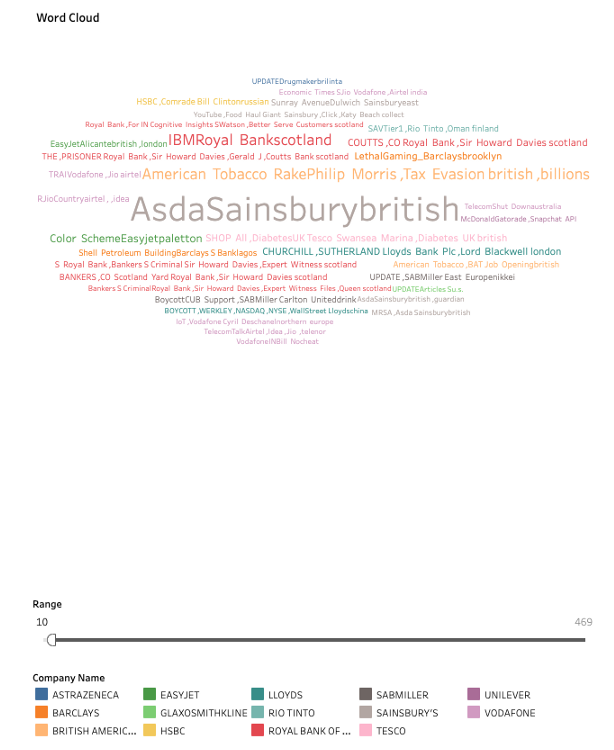

Plotting cluster size distribution...


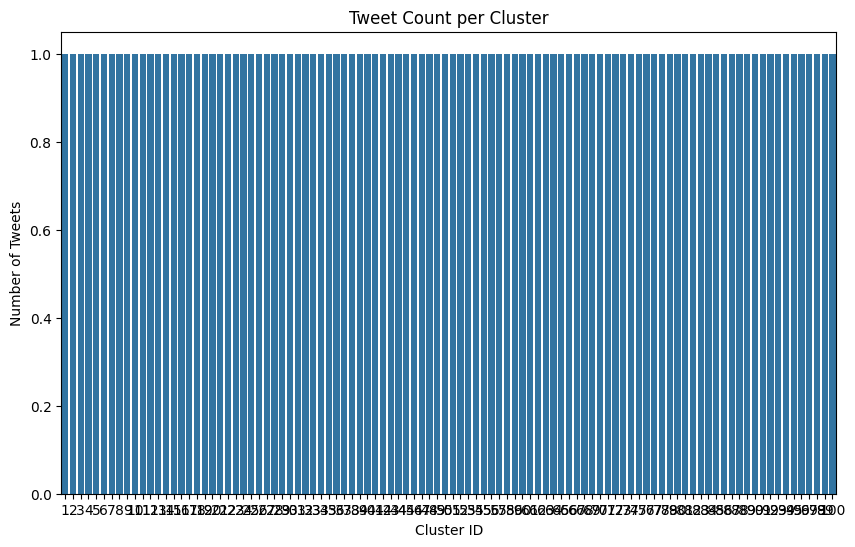

Plotting sentiment for each cluster...


/tmp/ipython-input-1722586021.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cluster_ref', y='sentiment_score', data=cluster_sentiment, palette='coolwarm')


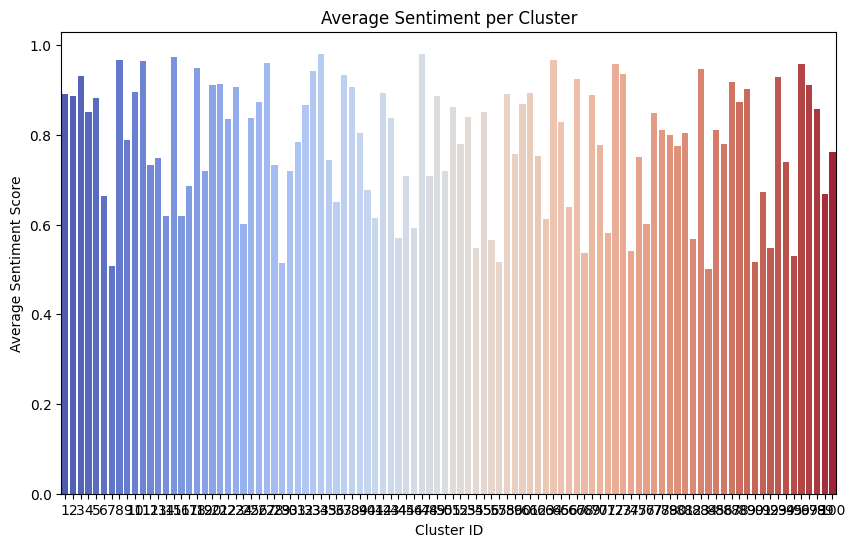

Plotting words in each cluster...


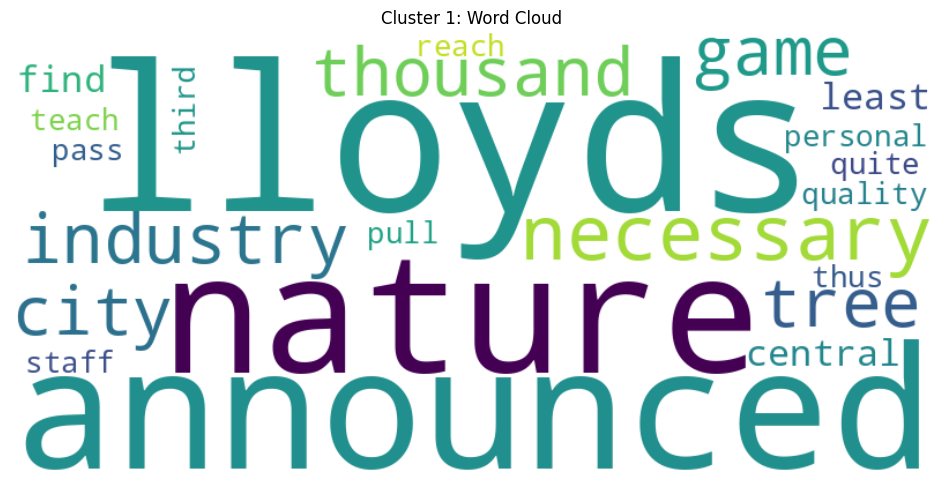

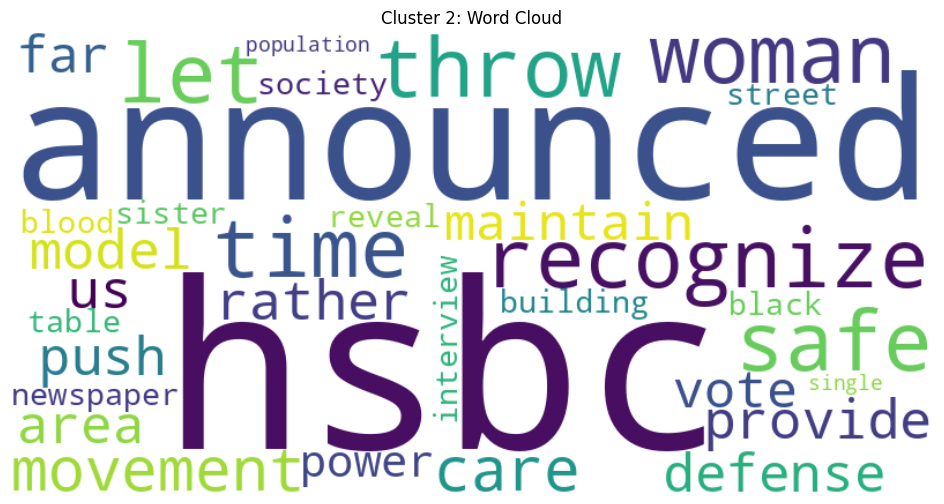

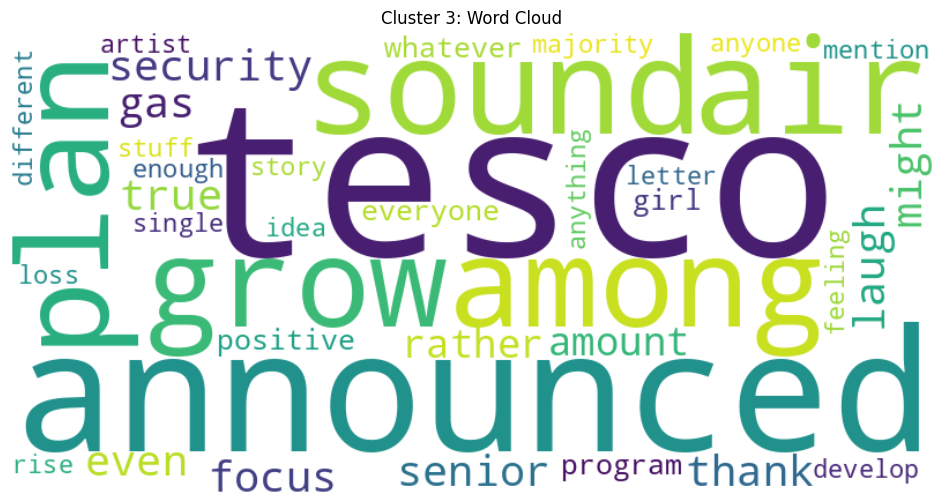

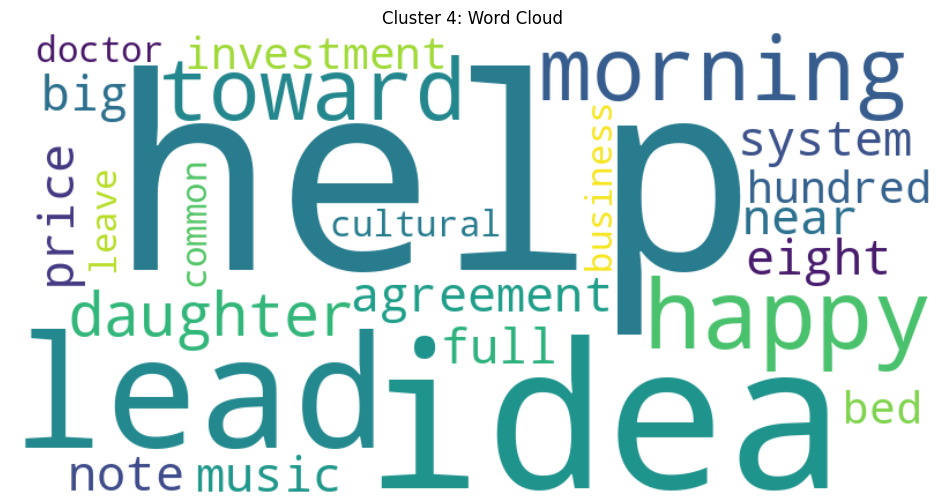

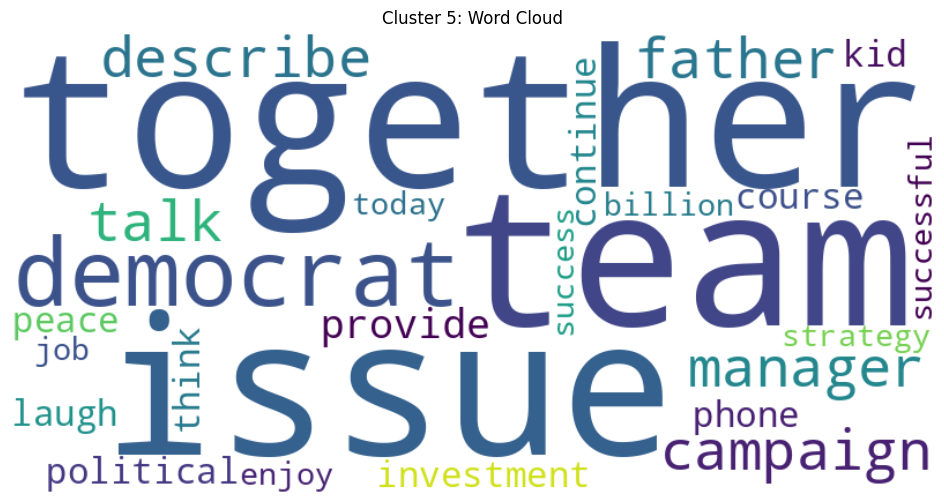

In [59]:

import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import numpy as np

print("Plotting cluster size distribution...")
plt.figure(figsize=(10,6))
cluster_sizes = tweet_df_comp['cluster_ref'].value_counts().sort_index()
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values)
plt.xlabel('Cluster ID')
plt.ylabel('Number of Tweets')
plt.title('Tweet Count per Cluster')
plt.show()

print("Plotting sentiment for each cluster...")
cluster_sentiment = (
    tweet_df_comp.groupby('cluster_ref')['sentiment_score']
    .mean()
    .reset_index()
    .sort_values('cluster_ref')
)

plt.figure(figsize=(10,6))
sns.barplot(x='cluster_ref', y='sentiment_score', data=cluster_sentiment, palette='coolwarm')
plt.xlabel('Cluster ID')
plt.ylabel('Average Sentiment Score')
plt.title('Average Sentiment per Cluster')
plt.show()

print("Plotting words in each cluster...")
# combine all text per cluster for visualization
cluster_texts = tweet_df_comp.groupby('cluster_ref')['text_clean'].apply(lambda x: ' '.join(x))

# generate word clouds for the top N clusters
top_clusters = cluster_sizes.head(5).index  # top 5 largest clusters

for cid in top_clusters:
    text = cluster_texts[cid]
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Cluster {cid}: Word Cloud')
    plt.show()



In order to over come the limitations seen above, we have weighted the sentiment by the number of tweets to calculate a weighted sentiment. This provides a more accurate measure of sentiment. For instance we can see in the first graph that Tesco has almost the same average positive and negative sentiment. However when scaled for the number of tweets we can see that the positive sentiment is much greater than the negative sentiment.

It is useful to see the proportion of positive, negative and neutral tweets for each company as shown below. This can lead to some interesting insights about the brand health of a company. For example we can see that for Schroders despite having a low weighted sentiment it has a very high proportion of positive tweets. This analysis when conducted over time can serve as an indicator of brand health.

The named entities which we have extracted using our named entity recognition algorithm can be visualised using a word cloud. In the below section I have created a word cloud in order to help with the analysis. The words are coloured by the companies and sized by the number of times it is repeated in the analysis. As default the word cloud is representing the entities which have been repeated at least 10 times. However this can be changed by moving the slider control at the bottom of the dashboard. The word cloud provide an easy way of understanding the most prominent topics being discussed in the tweets.

We can use the combined dashboard seen below to explore the topics driving the sentiment. We can see from instance from the word cloud that the Phrase “AsdaSainsburyBritish” is highlighted as the most prominent phrase. When we click on it we can see that it is due to tweets about a superbug found in the meat sold at these retailers. This can also be used to see what is driving the large negative positive sentiment in specific companies. For example by clicking on the red bar on the first chart for AstraZeneca and selecting the phrase from the word cloud we can see that the driving factor for negative sentiment here is a failed drug trial for Brilinta.

## Conclusion:

In conclusion the above techniques can be used to analyse huge volumes of twitter data. Additionally the algorithms can be applied to any kind of text data such as news articles or customer service chat data.

## Bonus - Tweepy

In [83]:
# Fall 2025: Tweepy requires a valid Twitter API key.
# The quotas for a free account are quite low, so please be aware of that.
# This cell is disabled by default, you need a BEARER_TOKEN.

BEARER_TOKEN = None # Change me

def handle_tweepy(token):
    # Search for Tweets from the Last 7 Days
    # OAuth2.0 Version
    import tweepy

    #Put your Bearer Token in the parenthesis below
    client = tweepy.Client(bearer_token=token)

    """
    If you don't understand search queries, there is an excellent introduction to it here:
    https://github.com/twitterdev/getting-started-with-the-twitter-api-v2-for-academic-research/blob/main/modules/5-how-to-write-search-queries.md
    """

    # Get tweets that contain the hashtag #petday
    # -is:retweet means I don't want retweets
    # lang:en is asking for the tweets to be in english
    query = '#petday -is:retweet lang:en'
    tweets = client.search_recent_tweets(query=query, tweet_fields=['context_annotations', 'created_at'], max_results=100)

    """
    What context_annotations are:
    https://developer.twitter.com/en/docs/twitter-api/annotations/overview
    """
    for tweet in tweets.data:
        print(tweet.text)
        if len(tweet.context_annotations) > 0:
            print(tweet.context_annotations)

if BEARER_TOKEN != None:
    handle_tweepy(token)
else:
    print("No token available, skipping.")

No token available, skipping.


In [84]:
def handle_tweepy_paginated(token):
    # Get More than 100 Tweets at a Time using paginator
    # OAuth2.0 Version
    import tweepy

    #Put your Bearer Token in the parenthesis below
    client = tweepy.Client(bearer_token=token)

    """
    If you don't understand search queries, there is an excellent introduction to it here:
    https://github.com/twitterdev/getting-started-with-the-twitter-api-v2-for-academic-research/blob/main/modules/5-how-to-write-search-queries.md
    """

    # Get tweets that contain the hashtag #petday
    # -is:retweet means I don't wantretweets
    # lang:en is asking for the tweets to be in english
    query = '#petday -is:retweet lang:en'
    tweets = tweepy.Paginator(client.search_recent_tweets, query=query,
                                tweet_fields=['context_annotations', 'created_at'], max_results=100).flatten(limit=1000)

    for tweet in tweets:
        print(tweet.text)
        if len(tweet.context_annotations) > 0:
            print(tweet.context_annotations)

if BEARER_TOKEN != None:
    handle_tweepy_paginated(BEARER_TOKEN)
else:
    print("No token available, skipping.")

No token available, skipping.


##  Instagram

In [85]:
# pip install instagramy

# Fall 2025: The library no longer works, and Instagram API is more locked down now.
# We provide mock data to imitate how it might work.

import random
import datetime
import pandas as pd

class InstagramUser:
    def __init__(self, account: str):
        self.account = account
        self._seed = hash(account) % (2**32)
        random.seed(self._seed)

        self._is_verified = random.random() < 0.2
        self._followers = random.randint(500, 5_000_000)
        self._following = random.randint(50, 1500)
        self._bio = random.choice([
            "Tech enthusiast | Coffee lover | Traveler",
            "Photographer | Dreamer | Creator",
            "Fitness addict | Mind over matter.",
            "Fashion & lifestyle blogger",
            "Music is life | Sharing my journey"
        ])

        self._posts = self._generate_posts()

    def _generate_posts(self, count: int = 10):
        posts = []
        for _ in range(count):
            likes = int(random.gauss(300, 100))
            likes = max(likes, 0)
            comments_count = random.randint(0, 10)
            comments = [
                random.choice(["🔥", "😍", "Love this!", "Nice!", "Amazing photo!"])
                for _ in range(comments_count)
            ]
            timestamp = datetime.datetime.now() - datetime.timedelta(days=random.randint(0, 365))
            posts.append({
                "id": random.randint(100000, 999999),
                "likes": likes,
                "comments": comments,
                "timestamp": timestamp.strftime("%Y-%m-%d"),
                "caption": random.choice([
                    "Enjoying the moment.",
                    "Throwback to this day",
                    "Simple things matter most!",
                    "New beginnings",
                    "Feeling grateful!"
                ])
            })
        return posts

    def is_verified(self):
        return self._is_verified

    def popularity(self):
        return self._followers

    def get_biography(self):
        return self._bio

    def followers_count(self):
        return self._followers

    def following_count(self):
        return self._following

    def get_posts_details(self):
        return self._posts

class Instalysis:
    def __init__(self, users):
        if not isinstance(users, list):
            raise TypeError("users must be a list of InstagramUser instances")
        self.users = users

    def analysis(self):
        records = []
        for user in self.users:
            posts = user.get_posts_details()
            total_likes = sum(p["likes"] for p in posts)
            total_comments = sum(len(p["comments"]) for p in posts)
            avg_likes = total_likes / len(posts)
            engagement_rate = (total_likes + total_comments) / max(user.popularity(), 1) * 100

            records.append({
                "username": user.account,
                "verified": user.is_verified(),
                "followers": user.followers_count(),
                "following": user.following_count(),
                "posts": len(posts),
                "avg_likes": round(avg_likes, 2),
                "total_comments": total_comments,
                "engagement_rate(%)": round(engagement_rate, 3)
            })

        df = pd.DataFrame(records)
        return df



In [86]:
# from instagramy import InstagramUser


# Connecting the profile
user = InstagramUser("geeks_for_geeks")

# printing the basic details like
# followers, following, bio
print(user.is_verified())
print(user.popularity())
print(user.get_biography())

# return list of dicts
posts = user.get_posts_details()

print('\n\nLikes', 'Comments')
for post in posts:
    likes = post["likes"]
    comments = post["comments"]
    print(likes,comments)

False
185357
Fashion & lifestyle blogger


Likes Comments
346 ['Love this!', 'Love this!', 'Amazing photo!', 'Amazing photo!', '😍', 'Amazing photo!', 'Nice!']
524 ['Amazing photo!', 'Love this!', 'Love this!', '😍', 'Nice!', 'Love this!', '😍', '🔥', 'Amazing photo!']
225 ['Nice!', '🔥', 'Nice!', '😍', 'Amazing photo!', 'Love this!']
209 ['Nice!', 'Love this!', 'Love this!', '😍', '😍', 'Love this!', 'Love this!', 'Nice!']
212 ['😍', 'Love this!', 'Amazing photo!', 'Amazing photo!', 'Nice!']
387 []
298 []
421 ['Amazing photo!', '😍', 'Love this!', 'Amazing photo!', 'Nice!', 'Love this!', '😍', '🔥', 'Nice!']
280 ['Amazing photo!', 'Nice!', '🔥', 'Love this!', 'Amazing photo!']
142 []


In [87]:
# from instagramy import Instalysis

# Instagram user_id of ipl teams
teams = ["chennaiipl", "mumbaiindians",
         "royalchallengersbangalore", "kkriders",
         "delhicapitals", "sunrisershyd",
         "kxipofficial"]

data = Instalysis([InstagramUser(k) for k in teams])

# return the dataframe
data_frame = data.analysis()
data_frame

,username,verified,followers,following,posts,avg_likes,total_comments,engagement_rate(%)
0,chennaiipl,False,3725486,274,10,292.9,57,0.080
1,mumbaiindians,False,2072846,1496,10,282.8,44,0.139
2,royalchallengersbangalore,False,1125813,734,10,306.8,41,0.276
3,kkriders,False,4343768,411,10,333.7,48,0.078
4,delhicapitals,False,318054,88,10,370.5,50,1.181
5,sunrisershyd,True,4911844,1001,10,283.7,38,0.059
6,kxipofficial,False,1096559,637,10,347.1,39,0.320


## Becareful when collecting SNS data (tweets, Instagram, Facebook...)
- Instagram forbids collecting user's personal information

## Kaggle Tweets

https://medium.com/analytics-vidhya/introduction-to-nlp-with-disaster-tweets-3b672a75748c


The text preprocessing is made up of six main steps which are: Lowercasing, Entities, URL Links and Punctuation Removal, Spelling Correction, Filling Missing Data, Lemmatization and Stop Words Removal. It is important to keep in mind that one can choose to include more steps to the text preprocessing (e.g. converting abbreviations to their original forms) or exclude some steps she/he thinks are unnecessary.

In the model section, transfer learning is used to create word embeddings. One can experiment by trying different pre-trained text embedding models. Some recommendation to further assess the performance of the model is to experiment with adding or removing dense layers, increasing or decreasing number of neurons, trying different known optimizers as well as trying different learning rates values.